# Final Notebook

### **CS-UY 4563 Final Project:**
### **FPL Player Points Predictor**

Predict each player's `total_points` for an upcoming Premier League gameweek using only pre-kickoff information. Football is high-variance and most pre-kickoff features are weak.

**Splits:**<br>
Train: 21/22 + 22/23 (46,991 rows).<br>
Val: 23/24 GW2-33 (23,825 rows). <br>
Test: 23/24 GW34-38 (4,259 rows).

### Some Context

Fantasy Premier League is one of the largest fantasy sports games in the world, with around 11 million active managers each season. Each manager picks a 15-player squad from real Premier League players under a £100m budget, sets a starting XI each gameweek, and earns points based on those players' real-world match performances: goals, assists, clean sheets, bonus points, minutes, and so on. The strategic core of the game is the  transfer decision: figure out which players to bring in for an upcoming gameweek, in essence a forecasting problem since you are betting on each candidate's expected output. FPL publishes its own pre-match prediction (xP) for every player every gameweek, which sets a clear bar for use to beat. In this project we aimed to build a forecasting engine, predicting total_points for an upcoming gameweek from pre-kickoff information only.

### What's in this notebook

**Prediction task.** Regression. Predict total_points for each (player, gameweek) using only pre-kickoff information. ~60% of rows have total_points = 0 (player did not play); the remaining ~40% are right-skewed integer scores typically in 1–15.

**Models.** Linear regression with L1/L2 regularization (Ridge, Lasso); a two-stage hurdle combining logistic regression with Ridge; Tweedie regression as a single-stage zero-inflation alternative; and an MLP regressor.

**Feature transformations tested.**
1. Raw standardized features (no-transformation baseline - Sections 3.1–3.3, 3.6).
2. PCA(n=5) on the ICT block (Section 3.5).
3. MLP architecture change from linear → (128, 64, 32) deep network (Section 3.7).
4. We also tried K-means to build cluster_id as a categorical feature (Section 4, we tested it in Phase 1 and dropped it because it was causing leakage issues).

**Validation strategy.** Time-aware splits (no random k-fold). Train: 2021/22 + 2022/23. Val: 2023/24 GW2–33. Test: 2023/24 GW34–38, untouched until Section 5. Class balance (~60% zeros) is preserved across all three splits because splits are temporal, not stratified.

## 1. Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso, LogisticRegression, Ridge, RidgeCV, TweedieRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

from src.config import (
    FEATURE_GROUPS, K_CLUSTERS, KMEANS_FEATURES, PROCESSED_PATH,
    get_feature_group, get_splits,
)

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

FIG_DIR = Path("../figures"); FIG_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path("../results"); RESULTS_DIR.mkdir(exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

In [2]:
def evaluate(y_true, y_pred):
    return {"R2": r2_score(y_true, y_pred), "MAE": mean_absolute_error(y_true, y_pred)}

def per_gw_metrics(gw_series, y_true, y_pred):
    out = []
    gw_arr = np.asarray(gw_series)
    for gw in sorted(np.unique(gw_arr)):
        m = (gw_arr == gw)
        out.append({"GW": int(gw), "n": int(m.sum()), "R2": r2_score(y_true[m], y_pred[m]), "MAE": mean_absolute_error(y_true[m], y_pred[m])})
    return pd.DataFrame(out)

def per_position_mae(pos_series, y_true, y_pred):
    out = []
    for pos in ["GK", "DEF", "MID", "FWD"]:
        m = (pos_series.values == pos)
        if m.sum() == 0:
            continue
        out.append({"pos": pos, "n": int(m.sum()), "MAE": mean_absolute_error(y_true[m], y_pred[m])})
    return pd.DataFrame(out)

def hurdle_predict(stage1_lr, scaler1, stage2_reg, scaler2, X_full):
    """P(played) * E[points | played] on a full feature matrix."""
    p_play = stage1_lr.predict_proba(scaler1.transform(X_full))[:, 1]
    cond = stage2_reg.predict(scaler2.transform(X_full))
    return p_play * cond, p_play, cond

## 2. Data and feature sets

The processed dataset is one row per (player, gameweek). Lag-1 and roll-3 features for 15 stats are computed within each player_season feature so feature values reflect only prior gameweeks.

Splits are frozen and treated as constants. The test set is the final 5 gameweeks of 23/24.

In [ ]:
df = pd.read_csv(PROCESSED_PATH)
train_mask, val_mask, test_mask = get_splits(df)
played_train_mask = train_mask & (df["played_any"] == 1)

# Feature sets via named groups
PHASE1_FEATURES = (
    get_feature_group("BASE_PREKICKOFF") + get_feature_group("POSITION")
    + get_feature_group("XP") + get_feature_group("ICT_BLOCK") + get_feature_group("OTHER_LAGS")
)
PHASE2_FEATURES = [c for c in PHASE1_FEATURES if c not in get_feature_group("XP")]

print(f"Train: {train_mask.sum():,} Val: {val_mask.sum():,} Test: {test_mask.sum():,}")
print(f"Played-only train: {played_train_mask.sum():,}")
print(f"Phase 1 features: {len(PHASE1_FEATURES)} Phase 2 features: {len(PHASE2_FEATURES)}")

Train: 46,991   Val: 23,825   Test: 4,259
Played-only train: 20,022
Phase 1 features: 45   Phase 2 features: 44


In [ ]:
y_train = df.loc[train_mask, "total_points"].values
y_val = df.loc[val_mask, "total_points"].values
y_test = df.loc[test_mask, "total_points"].values

y_train_play = df.loc[train_mask, "played_any"].values

val_results = []

## 3. Validation reproductions

Models below are presented in the order they were developed: baselines establish reference points, flat linear models test whether the target's structure can be modeled with one continuous regression, the hurdle decouples the play decision from the conditional scoring decision (Phase 1's winner), Tweedie tests a single-stage zero-inflation alternative, and PCA-on-ICT serves as a structured-features variant of the hurdle. The Phase 2 models then repeat the hurdle architecture with `xP` removed to isolate the value of FPL's pre-match predictor.

### 3.1 Baselines

Three references. The global mean is the floor, anything worse and the model is broken. The trailing 3-GW average is the simplest non-trivial baseline; any model that doesn't beat it adds nothing over a moving average. `xP` passthrough is FPL's own pre-match prediction used directly as a forecast: this is the actual bar to beat, since it represents the strongest pre-kickoff signal available without modeling.

In [5]:
# Global mean
val_results.append({"model": "Global mean", **evaluate(y_val, np.full_like(y_val, y_train.mean(), dtype=float))})

# Trailing 3-GW average (existing column)
val_results.append({"model": "Trailing 3-GW avg", **evaluate(y_val, df.loc[val_mask, "total_points_roll3"].values)})

# xP passthrough
xp_val = df.loc[val_mask, "xP"].values
val_results.append({"model": "xP passthrough", **evaluate(y_val, xp_val)})
pd.DataFrame(val_results[-3:]).round(4)

,model,R2,MAE
0,Global mean,-0.0102,1.5528
1,Trailing 3-GW avg,0.1139,1.0405
2,xP passthrough,0.5169,0.8129


### 3.2 Phase 1: flat Ridge / Lasso (xP-included)

Standard linear regression on the full Phase 1 feature set (BASE_PREKICKOFF + POSITION + xP + ICT_BLOCK + OTHER_LAGS). Both Ridge and Lasso land at essentially identical performance (R^2 $\approx$ 0.60). $\alpha$ was swept across np.logspace(-4, 4, 9) for both Ridge and Lasso; predictions were stable within $\pm$ 0.001R^2 until $\alpha \ge 10^4$, after which Ridge predictions begin to collapse toward the mean. This is a low-variance regime: the feature set is not overfit-prone, so regularization has little to push against. The bias floor is set by the linear functional form, not by the penalty.

The interesting result is the $R^2$/MAE divergence: Ridge gains $R^2$ over xP but is worse than xP on per-position MAE in three of four positions. The $R^2$ gain comes mostly from MID/DEF, where lag features carry recent-form signal xP doesn't seem to fully encode; on FWDs and GKs, xP already captures their narrower scoring distributions and lag features mostly add noise.

The Lasso coefficient plot below tells the central feature-space story: xP dominates with magnitude ~2.4 (standardized), and total_points_roll3 carries a strongly negative coefficient - with xP already encoding the matchup, recent over-performance reads as luck and the linear model predicts mean reversion. (Phase 2 will show this sign flips when xP is removed and the form signal redistributes.)

The flat linear model is also conceptually wrong for this target. About 60% of rows have total_points = 0 because the player did not play; flat linear treats these and active-player scoring as one continuous distribution. The hurdle in 3.3 addresses this directly.

In [6]:
# Shared scaler on full Phase 1 train features (used by flat Ridge/Lasso)
X_train_p1 = df.loc[train_mask, PHASE1_FEATURES].values
X_val_p1   = df.loc[val_mask,   PHASE1_FEATURES].values
scaler_p1_flat = StandardScaler().fit(X_train_p1)
Xt_p1, Xv_p1 = scaler_p1_flat.transform(X_train_p1), scaler_p1_flat.transform(X_val_p1)

ridge_flat = Ridge(alpha=1.0, random_state=SEED).fit(Xt_p1, y_train)
val_results.append({"model": "Phase1 Ridge flat (alpha=1)", **evaluate(y_val, ridge_flat.predict(Xv_p1))})

lasso_flat = Lasso(alpha=1e-4, random_state=SEED, max_iter=50000).fit(Xt_p1, y_train)
val_results.append({"model": "Phase1 Lasso flat (alpha=1e-4)", **evaluate(y_val, lasso_flat.predict(Xv_p1))})

pd.DataFrame(val_results[-2:]).round(4)

,model,R2,MAE
0,Phase1 Ridge flat (alpha=1),0.5989,0.8275
1,Phase1 Lasso flat (alpha=1e-4),0.5989,0.8273


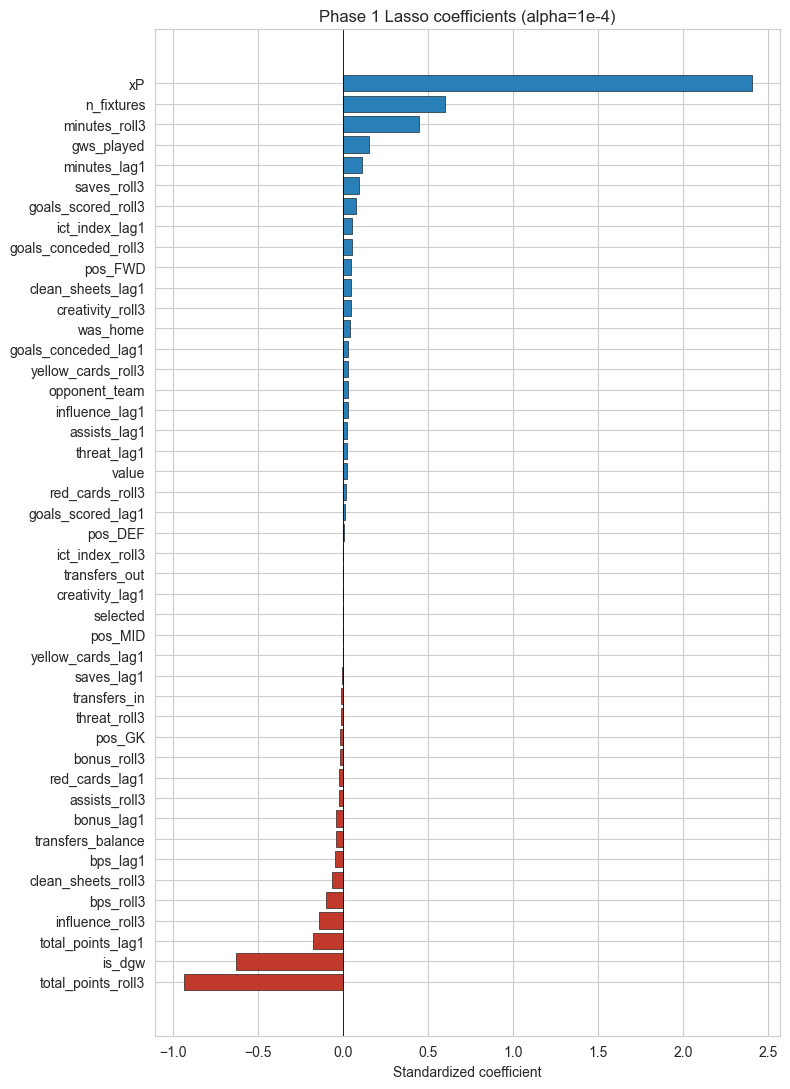

In [7]:
# Figure 1: Lasso coefficients at alpha=1e-4 (Phase 1 features)
coef = pd.Series(lasso_flat.coef_, index=PHASE1_FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 11))
colors = ["#c0392b" if v < 0 else "#2980b9" for v in coef.values]
ax.barh(coef.index, coef.values, color=colors, edgecolor="black", linewidth=0.4)
ax.axvline(0, color="black", linewidth=0.6)
ax.set_xlabel("Standardized coefficient")
ax.set_title("Phase 1 Lasso coefficients (alpha=1e-4)")
plt.tight_layout()
plt.savefig(FIG_DIR / "phase1_lasso_coefficients.png", dpi=120, bbox_inches="tight")
plt.show()

### 3.3 Phase 1: hurdle (winner)

Two-stage architecture decoupling the structural-zero generation from the conditional scoring distribution:

- **Stage 1** is logistic regression predicting `P(played_any = 1)`. SVM-RBF was tested as a comparison and produced indistinguishable performance (AUC 0.944 vs 0.947, Brier 0.085 vs 0.086) on a 10K-row stratified subsample: the play/no-play decision is well-approximated by a linear boundary in pre-kickoff feature space, so the SVM's nonlinearity contributed nothing. LR was selected because it used the full training data without subsample caveats.
- **Stage 2** is Ridge (alpha=1) trained on rows where `played_any = 1` only. It predicts expected points conditional on the player being on the pitch.
- **Combined** prediction is `P(played) × E[points | played]` on all val rows.

The threshold is `played_any`, not `played_60min`. The structural zero in this target is "no minutes played" - any minutes guarantee at least one appearance point, so `y > 0`. Cutting at 60 minutes would force stage 2 to never see cameo appearances and bias the conditional estimate downward.

Why it wins: +0.040 $R^2$ over flat Ridge but a 14% MAE reduction (0.83 -> 0.71). The biggest single MAE improvement is on goalkeepers (0.68 -> 0.45), where rotation patterns are sharpest and most cleanly captured by an explicit "is this player starting" model.

The two diagnostic plots establish that the hurdle behaves correctly. The reliability diagram shows stage 1's `predict_proba` outputs are usable as actual probabilities — this is what makes the multiplicative product `P(play) × E[points|play]` meaningful. The residuals-by-decile boxplot shows the lowest P(play) deciles have tightly clustered near-zero residuals: the multiplicative product handles DNPs naturally, with no inference-time threshold needed.

In [8]:
# Stage 1: LR on full train
scaler_p1_s1 = StandardScaler().fit(X_train_p1)
lr_p1 = LogisticRegression(max_iter=2000, random_state=SEED).fit(scaler_p1_s1.transform(X_train_p1), y_train_play)

# Stage 2: Ridge alpha=1 on played-only train
X_train_p1_p = df.loc[played_train_mask, PHASE1_FEATURES].values
y_train_p1_p = df.loc[played_train_mask, "total_points"].values
scaler_p1_s2 = StandardScaler().fit(X_train_p1_p)
ridge_p1 = Ridge(alpha=1.0, random_state=SEED).fit(scaler_p1_s2.transform(X_train_p1_p), y_train_p1_p)

# Combined val prediction
pred_p1_hurdle, p_play_p1_val, cond_p1_val = hurdle_predict(lr_p1, scaler_p1_s1, ridge_p1, scaler_p1_s2, X_val_p1)
val_results.append({"model": "Phase1 Hurdle (LR + Ridge alpha=1)", **evaluate(y_val, pred_p1_hurdle)})
pd.DataFrame(val_results[-1:]).round(4)

,model,R2,MAE
0,Phase1 Hurdle (LR + Ridge alpha=1),0.6386,0.7116


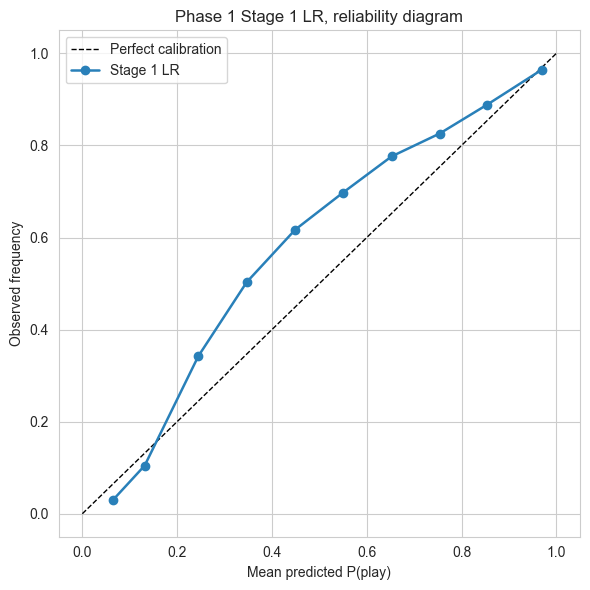

In [9]:
# Figure 2: Stage 1 LR reliability diagram (LR-only)
bins = np.linspace(0, 1, 11)
bin_idx = np.digitize(p_play_p1_val, bins) - 1
bin_idx = np.clip(bin_idx, 0, 9)
mean_pred = [p_play_p1_val[bin_idx == k].mean() if (bin_idx == k).any() else np.nan for k in range(10)]
obs_freq  = [df.loc[val_mask, "played_any"].values[bin_idx == k].mean() if (bin_idx == k).any() else np.nan for k in range(10)]

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ax.plot(mean_pred, obs_freq, marker="o", linewidth=1.8, color="#2980b9", label="Stage 1 LR")
ax.set_xlabel("Mean predicted P(play)")
ax.set_ylabel("Observed frequency")
ax.set_title("Phase 1 Stage 1 LR, reliability diagram")
ax.legend()
plt.tight_layout()
plt.show()

### 3.4 Phase 1: Tweedie

A single-stage alternative for zero-inflated continuous targets via the compound Poisson-Gamma family (`power` between 1 and 2). Negative train targets clipped to zero (220 rows, 0.47%); val targets unclipped for fair evaluation.

It underperformed: best stable Tweedie was $R^2$ = 0.5113, worse than flat Ridge and far below the hurdle. Likely due to two structural reasons. The log link compresses high-end variation: for a target where most values are 0–10, fitting `log(points)` blunts the points-2 vs points-12 distinction that matters for FPL. And Tweedie's single coefficient vector and single link function must balance the zero-mass and the positive tail simultaneously; the hurdle sidesteps this with separate models and links per regime.

In [10]:
# Tweedie power=1.1, α=0.01. Clip negative train targets to 0; val targets unclipped.
y_train_clip = np.clip(y_train, 0, None)
tweedie = TweedieRegressor(power=1.1, alpha=0.01, max_iter=2000).fit(Xt_p1, y_train_clip)
val_results.append({"model": "Phase1 Tweedie (p=1.1, alpha=0.01)", **evaluate(y_val, tweedie.predict(Xv_p1))})
pd.DataFrame(val_results[-1:]).round(4)

,model,R2,MAE
0,"Phase1 Tweedie (p=1.1, alpha=0.01)",0.5113,0.8619


### 3.5 Phase 1: hurdle + PCA(n=5) on ICT block

Compared against the Section 3.3 hurdle, which uses raw standardized features. The progress-report correlation heatmap flagged the ICT block (12 columns: lag1 and roll3 versions of influence, creativity, threat, ict_index, bps, minutes) as heavily collinear. PCA is applied to that block only, leaving BASE_PREKICKOFF, POSITION, xP, and OTHER_LAGS raw and standardized normally. A single PCA is fit on the full-train ICT block and applied identically to both hurdle stages. Five components on the elbow rule retain 96% of variance (see Section 4.2 for the scree plot and loadings interpretation). The Performance impact was negligible: hurdle val $R^2$ 0.6386 -> 0.6384 (per-position MAEs all within 0.001). Ridge's L2 was already handling the collinearity. 

In [ ]:
ICT = get_feature_group("ICT_BLOCK")
NON_ICT_P1 = [c for c in PHASE1_FEATURES if c not in ICT]

# Fit PCA on full-train ICT block
scaler_ict = StandardScaler().fit(df.loc[train_mask, ICT].values)
pca_ict = PCA(n_components=5, random_state=SEED).fit(scaler_ict.transform(df.loc[train_mask, ICT].values))

def transform_pca(rows_mask):
    non_ict = df.loc[rows_mask, NON_ICT_P1].values
    ict_pcs = pca_ict.transform(scaler_ict.transform(df.loc[rows_mask, ICT].values))
    return np.hstack([non_ict, ict_pcs])

X_train_pca       = transform_pca(train_mask)
X_train_played_pca = transform_pca(played_train_mask)
X_val_pca         = transform_pca(val_mask)

# Stage 1
scaler_pca_s1 = StandardScaler().fit(X_train_pca)
lr_pca = LogisticRegression(max_iter=2000, random_state=SEED).fit(scaler_pca_s1.transform(X_train_pca), y_train_play)

# Stage 2
scaler_pca_s2 = StandardScaler().fit(X_train_played_pca)
ridge_pca = Ridge(alpha=1.0, random_state=SEED).fit(scaler_pca_s2.transform(X_train_played_pca), y_train_p1_p)

pred_pca_hurdle, _, _ = hurdle_predict(lr_pca, scaler_pca_s1, ridge_pca, scaler_pca_s2, X_val_pca)
val_results.append({"model": "Phase1 Hurdle + PCA(5) on ICT", **evaluate(y_val, pred_pca_hurdle)})
pd.DataFrame(val_results[-1:]).round(4)

,model,R2,MAE
0,Phase1 Hurdle + PCA(5) on ICT,0.6384,0.7118


### 3.6 Phase 2: hurdle linear (no xP)

Phase 1's winning architecture (LR stage 1 + Ridge stage 2) refit with `xP` removed from both stages. Stage 1 is retrained, Phase 1's fitted stage 1 saw `xP` and cannot be reused. RidgeCV searches `np.logspace(-3, 3, 13)` on the conditional task.

Stage 1 AUC drops only modestly (0.947 -> 0.930): the play/no-play decision retains almost all of its signal without `xP`. The combined hurdle $R^2$ roughly halves to ~0.30. A separate diagnostic showed stage 2 alone $R^2$ on played-only val collapses to 0.085. The conditional points-given-play task contains very little linear signal once `xP` is gone. RidgeCV picks $\alpha$≈316 and $\alpha$=1 produces identical predictions to three decimal places: not over-correction, but a flat loss surface with no real signal to fit.

This sets up the central Phase 2 finding: `xP` encodes pre-kickoff information (team strength, fixture difficulty, set-piece taker status, bookmaker-implied scoring rates) that is not recoverable from the lag/roll features of player statistics this dataset contains, regardless of regularization or model class.

In [12]:
# Stage 1: LR (no xP)
X_train_p2 = df.loc[train_mask, PHASE2_FEATURES].values
X_val_p2   = df.loc[val_mask,   PHASE2_FEATURES].values
scaler_p2_s1 = StandardScaler().fit(X_train_p2)
lr_p2 = LogisticRegression(max_iter=2000, random_state=SEED).fit(scaler_p2_s1.transform(X_train_p2), y_train_play)

# Stage 2: RidgeCV over logspace(-3, 3, 13)
X_train_p2_p = df.loc[played_train_mask, PHASE2_FEATURES].values
scaler_p2_s2 = StandardScaler().fit(X_train_p2_p)
ridgecv_p2 = RidgeCV(alphas=np.logspace(-3, 3, 13)).fit(scaler_p2_s2.transform(X_train_p2_p), y_train_p1_p)

pred_p2_lin, _, _ = hurdle_predict(lr_p2, scaler_p2_s1, ridgecv_p2, scaler_p2_s2, X_val_p2)
val_results.append({"model": "Phase2 Hurdle linear (no xP)", **evaluate(y_val, pred_p2_lin)})
print(f"RidgeCV alpha: {ridgecv_p2.alpha_:.2f}")
pd.DataFrame(val_results[-1:]).round(4)

RidgeCV alpha: 316.23


,model,R2,MAE
0,Phase2 Hurdle linear (no xP),0.3019,0.9745


### 3.7 Phase 2: hurdle MLP (no xP)

Per project rules, changing neural network architecture counts as a feature transformation so we are going with that here to see if we can get any improvement.The grid below includes (64,) which is a single-hidden-layer MLP, which serves as the no-transformation NN baseline. Hence the (128, 64, 32) deep network is a transformed variant. Val R^2 across the entire grid spans only 0.288–0.302, so the architecture transformation produced no meaningful gain.

Architecture was selected from a 3×3 grid over depth {(64,), (128, 64), (128, 64, 32)} and L2 $\alpha$ {1e-5, 1e-4, 1e-3}, run in the Phase 2 development phase. The (128, 64, 32) / $\alpha$=1e-4 cell won, but val R^2 across the grid spanned only 0.288–0.302 - a flat surface consistent with the finding (Section 3.6) that the conditional task contains very little signal once xP is removed, regardless of model class. Final config: hidden layers (128, 64, 32), L2 $\alpha$=1e-4, Adam, lr=1e-3, ReLU, sklearn early stopping with random 10% validation fraction, seed pinned.

The MLP does not in fact close the gap: combined R^2 0.290 vs the linear baseline's 0.302. Our assumption on the bias/variance reading is that the linear model is already at the bias floor for this feature set. Effectively there is no nonlinear interaction structure available for an MLP to discover when the informative pre-kickoff signal (encoded in xP) has been removed from the input space.

In [13]:
# Stage 2: MLP
mlp_p2 = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32), alpha=1e-4, solver="adam",
    learning_rate_init=1e-3, activation="relu",
    early_stopping=True, validation_fraction=0.1,
    random_state=SEED, max_iter=500,
).fit(scaler_p2_s2.transform(X_train_p2_p), y_train_p1_p)

pred_p2_mlp, _, _ = hurdle_predict(lr_p2, scaler_p2_s1, mlp_p2, scaler_p2_s2, X_val_p2)
val_results.append({"model": "Phase2 Hurdle MLP (no xP)", **evaluate(y_val, pred_p2_mlp)})
pd.DataFrame(val_results[-1:]).round(4)

,model,R2,MAE
0,Phase2 Hurdle MLP (no xP),0.2902,0.9579


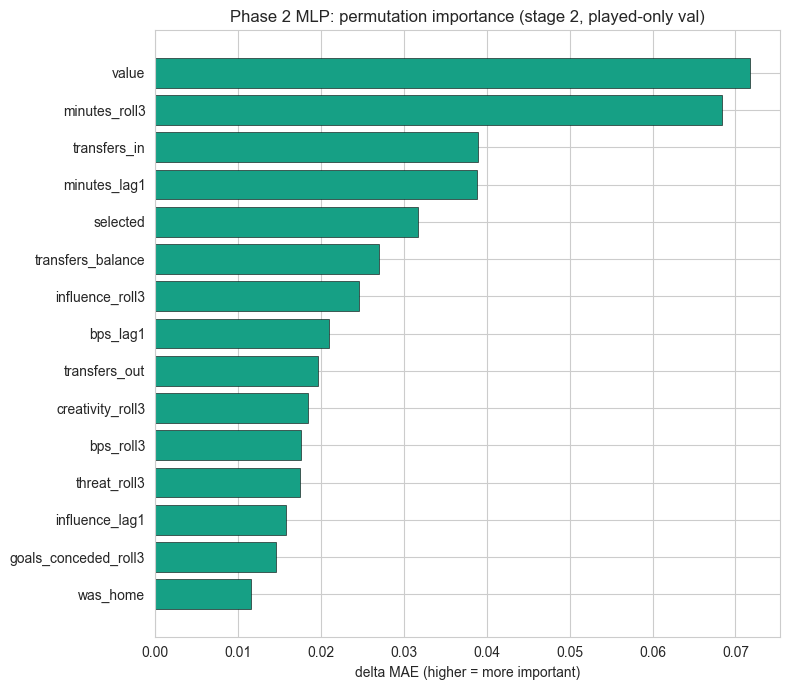

In [14]:
# Figure 6: MLP permutation importance
played_val_mask = val_mask & (df["played_any"] == 1)
X_val_p2_played = scaler_p2_s2.transform(df.loc[played_val_mask, PHASE2_FEATURES].values)
y_val_played = df.loc[played_val_mask, "total_points"].values

perm = permutation_importance(
    mlp_p2, X_val_p2_played, y_val_played,
    n_repeats=5, random_state=SEED, scoring="neg_mean_absolute_error",
)
imp = pd.Series(perm.importances_mean, index=PHASE2_FEATURES).sort_values()
top = imp.tail(15)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top.index, top.values, color="#16a085", edgecolor="black", linewidth=0.4)
ax.set_xlabel("delta MAE (higher = more important)")
ax.set_title("Phase 2 MLP: permutation importance (stage 2, played-only val)")
plt.tight_layout()
plt.savefig(FIG_DIR / "phase2_permutation_importance.png", dpi=120, bbox_inches="tight")
plt.show()

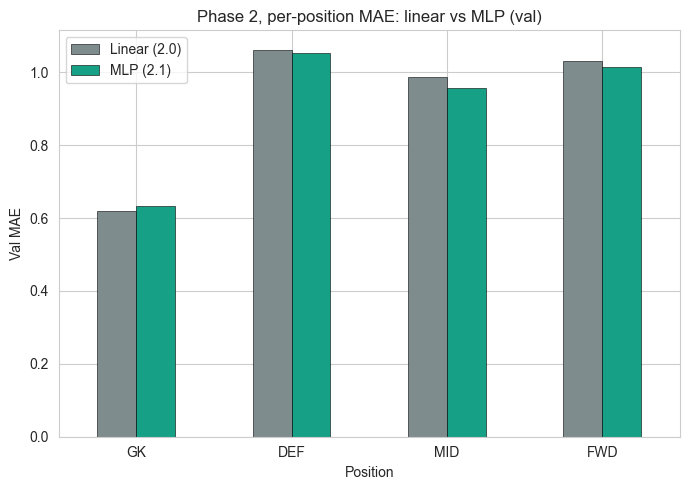

In [15]:
# Figure 7: per-position MAE comparison, Phase 2 linear vs MLP (val)
pos_val = df.loc[val_mask, "position"]
pp_lin = per_position_mae(pos_val, y_val, pred_p2_lin).set_index("pos")["MAE"]
pp_mlp = per_position_mae(pos_val, y_val, pred_p2_mlp).set_index("pos")["MAE"]
pp = pd.DataFrame({"Linear (2.0)": pp_lin, "MLP (2.1)": pp_mlp}).reindex(["GK", "DEF", "MID", "FWD"])

fig, ax = plt.subplots(figsize=(7, 5))
pp.plot(kind="bar", ax=ax, color=["#7f8c8d", "#16a085"], edgecolor="black", linewidth=0.4)
ax.set_ylabel("Val MAE")
ax.set_xlabel("Position")
ax.set_title("Phase 2, per-position MAE: linear vs MLP (val)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "phase2_per_position_mae.png", dpi=120, bbox_inches="tight")
plt.show()

### 3.8 Master comparison table

The full val comparison.

In [16]:
val_table = pd.DataFrame(val_results).round(4)
val_table.to_csv(RESULTS_DIR / "comparison_table.csv", index=False)
val_table

,model,R2,MAE
0,Global mean,-0.0102,1.5528
1,Trailing 3-GW avg,0.1139,1.0405
2,xP passthrough,0.5169,0.8129
3,Phase1 Ridge flat (alpha=1),0.5989,0.8275
4,Phase1 Lasso flat (alpha=1e-4),0.5989,0.8273
5,Phase1 Hurdle (LR + Ridge alpha=1),0.6386,0.7116
6,"Phase1 Tweedie (p=1.1, alpha=0.01)",0.5113,0.8619
7,Phase1 Hurdle + PCA(5) on ICT,0.6384,0.7118
8,Phase2 Hurdle linear (no xP),0.3019,0.9745
9,Phase2 Hurdle MLP (no xP),0.2902,0.9579


## 4. Unsupervised analyses (standalone for writeup)

K-means `cluster_id` was tested as a model feature in Phase 1 and dropped, it cost val $R^2$ in both Ridge and Lasso, primarily because the cluster column carries different statistical meaning in train (current archetype) vs val (last year's archetype) by leakage-safety design. The PCA on the ICT block was tested as a hurdle variant in Section 3.5 and was performance-neutral.

### 4.1 K-means archetypes (K=4, train-only fit)

Fit on player-season aggregates restricted to player-seasons with at least 5 gameweeks of data. Features are five numeric playing-style stats: mean minutes per gameweek, mean influence/creativity/threat per appearance, and mean value. **Position one-hots are deliberately excluded from the K-means feature set.** Including them caused position rediscovery (silhouette 0.45 but clusters were ~99% single-position). Removing them dropped silhouette to 0.325 but produced cross-positional archetypes, the algorithm found within-position style structure rather than re-learning the position field.

The four archetypes:

- Defensive starters: heavily GK + DEF, full minutes, low attacking output.
- Rotational / fringe: low-minute attackers across MID and FWD.
- Premium attackers: high threat, high price, captaincy candidates. Notably contains a few defenders (attacking fullbacks like Trent and Cancelo whose output groups them with elite MIDs rather than other defenders).
- Creative regulars: cross-positional starters with attacking output.

Holdout assignment uses each player's most recent prior-season aggregates rather than within-23/24 information, preserving leakage safety. Player-seasons with no eligible prior history are routed to a distinct "unclassified" bucket, this holds roughly 25% of 23/24 minutes and is a structural feature of English football (three promoted clubs plus summer transfers from foreign leagues every year).

The summary below uses `minutes_roll3` as the in-data proxy for typical playing time, since the raw `minutes` column is dropped from the modeling table to prevent leakage.

In [17]:
# K-means was fit train-only in data_prep.py; cluster_id is already on the table.
# Summarize per-cluster aggregates over TRAIN rows (raw minutes were dropped from the
# modeling table, so minutes_roll3 stands in as the in-data proxy).
CLUSTER_LABELS = {
    0: "Defensive starters", 1: "Rotational/fringe",
    2: "Premium attackers",  3: "Creative regulars", 4: "Unclassified",
}

train_df = df.loc[train_mask].copy()
summary = (
    train_df.groupby("cluster_id")
    .agg(n=("total_points", "size"),
         mean_total_points=("total_points", "mean"),
         mean_minutes_roll3=("minutes_roll3", "mean"),
         mean_value=("value", "mean"))
    .round(3)
)
summary["label"] = summary.index.map(CLUSTER_LABELS)

pos_share = (
    pd.crosstab(train_df["cluster_id"], train_df["position"], normalize="index")
    .reindex(columns=["GK", "DEF", "MID", "FWD"]).round(3)
)
kmeans_summary = summary.join(pos_share)[["label", "n", "mean_total_points", "mean_minutes_roll3", "mean_value", "GK", "DEF", "MID", "FWD"]]
kmeans_summary

,label,n,mean_total_points,mean_minutes_roll3,mean_value,GK,DEF,MID,FWD
cluster_id,,,,,,,,,
0,Defensive starters,11299,1.945,55.633,46.239,0.190,0.697,0.113,0.000
1,Rotational/fringe,11027,0.870,19.050,49.678,0.000,0.203,0.607,0.190
2,Premium attackers,2985,3.801,62.127,83.217,0.000,0.035,0.577,0.388
3,Creative regulars,6956,2.643,60.974,54.211,0.000,0.202,0.682,0.116
4,Unclassified,14724,0.012,0.302,44.387,0.204,0.303,0.369,0.124


### 4.2 PCA on ICT block

Same fit as the PCA-hurdle in Section 3.5: train rows only, ICT block only (12 columns), 5 components retained on the elbow rule (96% of variance).

Two interpretable axes emerge:

- PC1, player involvement: All twelve ICT variables load positively in a tight 0.25–0.32 range. Reads as "everything goes up together when the player is on the pitch and contributing." This is the dominant component (≈70% of variance).
- PC2, within-position attacking style: Positive loadings on threat (0.42–0.45) and creativity (0.25–0.27); negative loadings on bps and minutes (−0.27 to −0.31). This captures attacking specialists who post threat and creativity despite lower minutes, an axis that distinguishes player styles within positions, not redundant with the `position` one-hots.

PC3–PC5 carry ~6%, ~6%, ~3% respectively and are less cleanly interpretable. The scree plot shows the elbow before PC5 that motivates the n=5 choice.

In [18]:
# PCA already fit on train ICT block (Section 3.5).
explained = pca_ict.explained_variance_ratio_
print("Explained variance ratios PC1-PC5:", np.round(explained, 4))
print(f"Cumulative through PC5: {explained.sum():.4f}")

Explained variance ratios PC1-PC5: [0.6973 0.1025 0.0686 0.0626 0.0299]
Cumulative through PC5: 0.9609


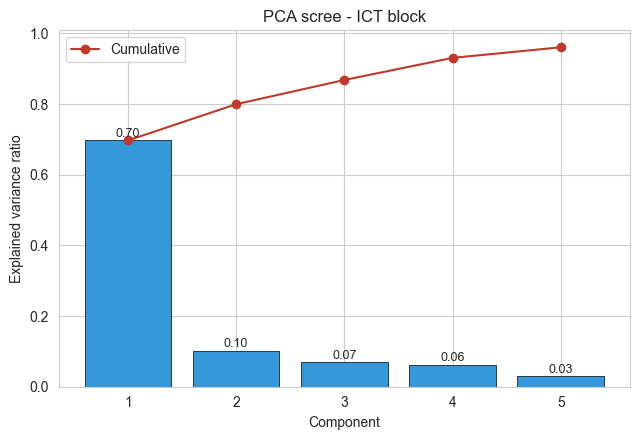

In [19]:
# Figure 4: scree plot
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(range(1, 6), explained, color="#3498db", edgecolor="black", linewidth=0.5)
ax.plot(range(1, 6), np.cumsum(explained), marker="o", color="#c0392b", label="Cumulative")
for i, v in enumerate(explained):
    ax.text(i + 1, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
ax.set_xlabel("Component")
ax.set_ylabel("Explained variance ratio")
ax.set_title("PCA scree - ICT block")
ax.set_xticks(range(1, 6))
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "phase1_pca_scree.png", dpi=120, bbox_inches="tight")
plt.show()

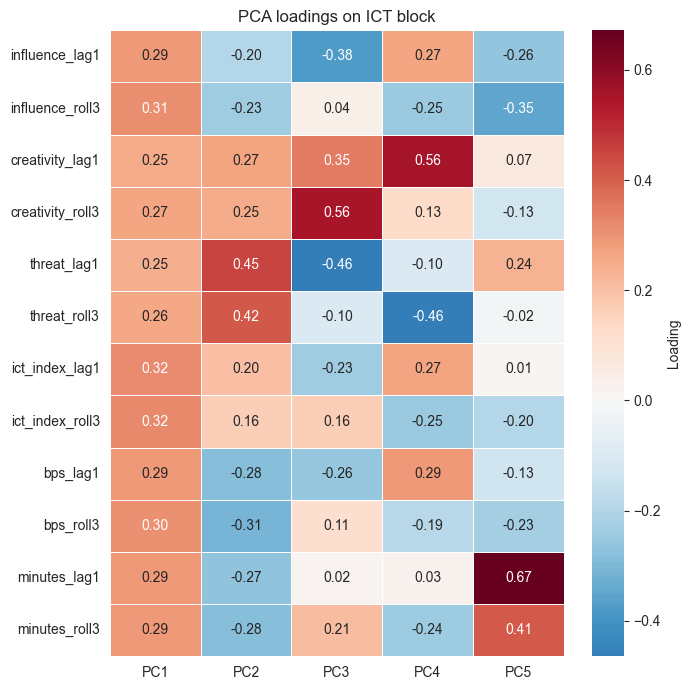

In [20]:
# Figure 5: loadings heatmap PC1-PC5
loadings = pd.DataFrame(pca_ict.components_.T, index=ICT, columns=[f"PC{i+1}" for i in range(5)])
fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "Loading"}, linewidths=0.4, ax=ax)
ax.set_title("PCA loadings on ICT block")
plt.tight_layout()
plt.savefig(FIG_DIR / "phase1_pca_loadings.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Test evaluation

The test set (23/24 GW 34-38) was untouched until this section. Three models were pre-declared based on val-set decisions:

1. xP passthrough: the bar to beat, no fitting required.
2. Phase 1 hurdle with xP: Phase 1's winner.
3. Phase 2 hurdle linear (without xP): The linear hurdle isolates the xP effect cleanly.

Each model is applied to TEST using the same fitted object that produced its val number, no refitting on TRAIN+VAL. No model selection or tuning occurred against the test set. The three test models were declared from val-set decisions before any test prediction was generated.

In [21]:
# Apply each model to TEST features
X_test_p1 = df.loc[test_mask, PHASE1_FEATURES].values
X_test_p2 = df.loc[test_mask, PHASE2_FEATURES].values

test_predictions = {
    "xP passthrough": df.loc[test_mask, "xP"].values,
    "Phase1 Hurdle (with xP)": hurdle_predict(lr_p1, scaler_p1_s1, ridge_p1, scaler_p1_s2, X_test_p1)[0],
    "Phase2 Hurdle linear (no xP)": hurdle_predict(lr_p2, scaler_p2_s1, ridgecv_p2, scaler_p2_s2, X_test_p2)[0],
}

test_agg = pd.DataFrame([{"model": m, **evaluate(y_test, p)} for m, p in test_predictions.items()]).round(4)
test_agg

,model,R2,MAE
0,xP passthrough,0.5988,0.8286
1,Phase1 Hurdle (with xP),0.6917,0.7365
2,Phase2 Hurdle linear (no xP),0.3823,1.0383


In [22]:
# Per-GW R² and MAE (each test model)
gw_test = df.loc[test_mask, "GW"]
per_gw_frames = []
for m, p in test_predictions.items():
    f = per_gw_metrics(gw_test, y_test, p)
    f["model"] = m
    per_gw_frames.append(f)
per_gw = pd.concat(per_gw_frames, ignore_index=True)[["model", "GW", "n", "R2", "MAE"]].round(4)
per_gw

,model,GW,n,R2,MAE
0,xP passthrough,34,815,0.6486,0.9787
1,xP passthrough,35,859,0.5032,0.7977
2,xP passthrough,36,859,0.5684,0.7695
3,xP passthrough,37,861,0.6954,0.7589
4,xP passthrough,38,865,0.5006,0.8462
5,Phase1 Hurdle (with xP),34,815,0.7328,0.8342
6,Phase1 Hurdle (with xP),35,859,0.6033,0.7191
7,Phase1 Hurdle (with xP),36,859,0.6558,0.7146
8,Phase1 Hurdle (with xP),37,861,0.7762,0.6785
9,Phase1 Hurdle (with xP),38,865,0.6243,0.7413


In [23]:
# Per-position MAE (each test model)
pos_test = df.loc[test_mask, "position"]
per_pos_frames = []
for m, p in test_predictions.items():
    f = per_position_mae(pos_test, y_test, p)
    f["model"] = m
    per_pos_frames.append(f)
per_pos = pd.concat(per_pos_frames, ignore_index=True)[["model", "pos", "n", "MAE"]].round(4)
per_pos

,model,pos,n,MAE
0,xP passthrough,GK,486,0.6782
1,xP passthrough,DEF,1370,0.8648
2,xP passthrough,MID,1843,0.8422
3,xP passthrough,FWD,560,0.8262
4,Phase1 Hurdle (with xP),GK,486,0.4728
5,Phase1 Hurdle (with xP),DEF,1370,0.7881
6,Phase1 Hurdle (with xP),MID,1843,0.7535
7,Phase1 Hurdle (with xP),FWD,560,0.7835
8,Phase2 Hurdle linear (no xP),GK,486,0.6586
9,Phase2 Hurdle linear (no xP),DEF,1370,1.1639


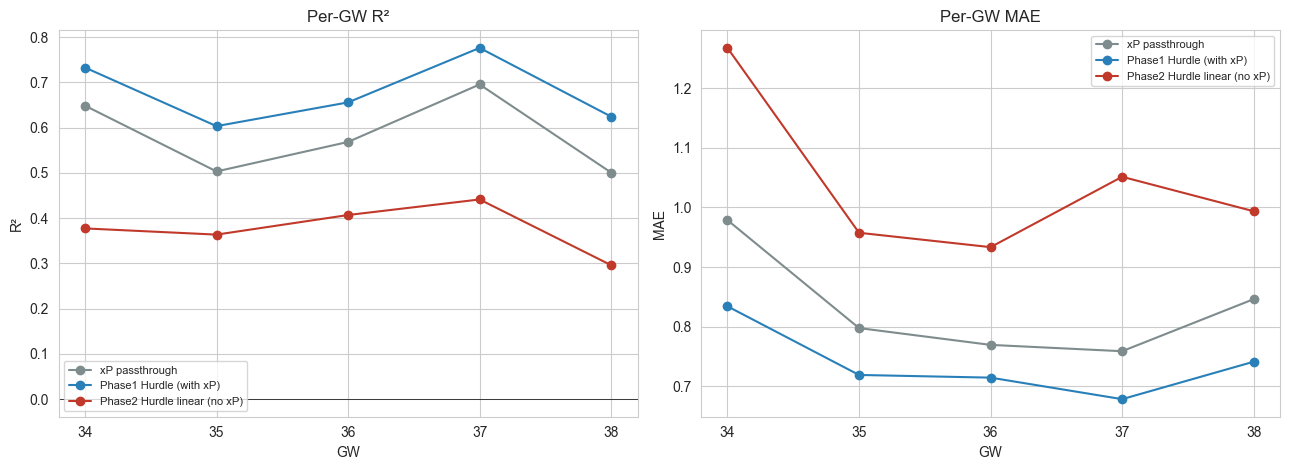

In [24]:
# Figure 8: per-GW R² and MAE for the three test models
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
colors = {"xP passthrough": "#7f8c8d", "Phase1 Hurdle (with xP)": "#2980b9", "Phase2 Hurdle linear (no xP)": "#c0392b"}
for m in test_predictions:
    sub = per_gw[per_gw["model"] == m]
    axes[0].plot(sub["GW"], sub["R2"],  marker="o", label=m, color=colors[m])
    axes[1].plot(sub["GW"], sub["MAE"], marker="o", label=m, color=colors[m])
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("Per-GW R²"); axes[0].set_xlabel("GW"); axes[0].set_ylabel("R²")
axes[1].set_title("Per-GW MAE"); axes[1].set_xlabel("GW"); axes[1].set_ylabel("MAE")
axes[0].legend(loc="best", fontsize=8); axes[1].legend(loc="best", fontsize=8)
for ax in axes: ax.set_xticks(sub["GW"].values)
plt.tight_layout()
plt.savefig(FIG_DIR / "test_per_gw_performance.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Summary

Phase 1 hurdle minus `xP` is the contribution of our modeling on top of FPL's own predictor. Phase 1 hurdle minus Phase 2 hurdle linear is the value of `xP` itself, the pre-kickoff information that lives in FPL's predictor but cannot be recovered from raw historical features in this dataset. Both are computed from the same test predictions, so they share evaluation conditions exactly.

In [25]:
# Save test artifacts alongside the val table
test_agg.to_csv(RESULTS_DIR / "test_aggregate.csv", index=False)
per_gw.to_csv(RESULTS_DIR / "test_per_gw.csv", index=False)
per_pos.to_csv(RESULTS_DIR / "test_per_position.csv", index=False)

# Value-of-xP quantification from test numbers
r2_with = test_agg.loc[test_agg["model"] == "Phase1 Hurdle (with xP)", "R2"].iloc[0]
r2_without = test_agg.loc[test_agg["model"] == "Phase2 Hurdle linear (no xP)", "R2"].iloc[0]
r2_xp = test_agg.loc[test_agg["model"] == "xP passthrough", "R2"].iloc[0]
mae_with= test_agg.loc[test_agg["model"] == "Phase1 Hurdle (with xP)", "MAE"].iloc[0]
mae_without = test_agg.loc[test_agg["model"] == "Phase2 Hurdle linear (no xP)", "MAE"].iloc[0]
mae_xp = test_agg.loc[test_agg["model"] == "xP passthrough", "MAE"].iloc[0]

print("Test set (23/24 GW 34-38)")
print(f"xP passthrough: R^2 = {r2_xp:+.4f} MAE = {mae_xp:.4f}")
print(f"Phase 1 hurdle (with xP): R^2 = {r2_with:+.4f} MAE = {mae_with:.4f} delta vs xP: R^2 {r2_with - r2_xp:+.4f}, MAE {mae_with - mae_xp:+.4f}")
print(f"Phase 2 hurdle (no xP): R^2 = {r2_without:+.4f}  MAE = {mae_without:.4f} delta vs xP: R^2 {r2_without - r2_xp:+.4f}, MAE {mae_without - mae_xp:+.4f}")
print(f"\nValue of xP (Phase 1 - Phase 2): deltaR^2 = {r2_with - r2_without:+.4f} deltaMAE = {mae_without - mae_with:+.4f}")

Test set (23/24 GW 34-38)
xP passthrough: R^2 = +0.5988 MAE = 0.8286
Phase 1 hurdle (with xP): R^2 = +0.6917 MAE = 0.7365 delta vs xP: R^2 +0.0929, MAE -0.0921
Phase 2 hurdle (no xP): R^2 = +0.3823  MAE = 1.0383 delta vs xP: R^2 -0.2165, MAE +0.2097

Value of xP (Phase 1 - Phase 2): deltaR^2 = +0.3094 deltaMAE = +0.3018
